### Выгружаем данные и приводим к бинарной классификации

In [ ]:
!pip install -q gdown
!gdown 1RegAidGhW66uluQ1aNRV45SyM5YM4pP-

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(


In [1]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

zip_path = 'dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("📁 Архив распакован.")


Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: 'https://drive.google.com/file/d/1RegAidGhW66uluQ1aNRV45SyM5YM4pP-/view?usp=sharing'

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms


In [ ]:
images_folder = '/content/dataset/dataset/images/'

df = pd.read_csv('/content/dataset/dataset/metadata.csv')
df['label'] = (df['label'] == 0).astype(int)
df.head()

,filename,url,label
0,f2aa95b29e23ab55e0835e568490fbf4.jpg,https://sun9-78.userapi.com/s/v1/ig2/4E1uthQGB...,1
1,e4c3c63a54aac3879eddf9c41fe95c8d.jpg,https://sun9-12.userapi.com/s/v1/ig2/5OWFaVDJt...,1
2,9b48a6590f500395fcc0b64454554ebb.jpg,https://sun9-56.userapi.com/s/v1/ig2/38F1TO2qH...,1
3,af5a3f59969b5ab516bd8a7b31b1d899.jpg,https://sun9-38.userapi.com/s/v1/ig2/-CIDI4vJM...,1
4,1d4601c747f9457b35d2192675776f2c.jpg,https://sun9-23.userapi.com/s/v1/ig2/jKo2LpIVY...,1


In [ ]:
class VkDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])

        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

data = VkDataset(df, images_folder, transform=transform)
dataloader = DataLoader(data, batch_size=32, shuffle=True)

for images, labels in dataloader:
    print(f"🖼️ Batch size: {images.size()}, Labels: {labels}")
    break

groups = ['not cu', 'central_university']


NameError: name 'transforms' is not defined

### проверяем что все верно

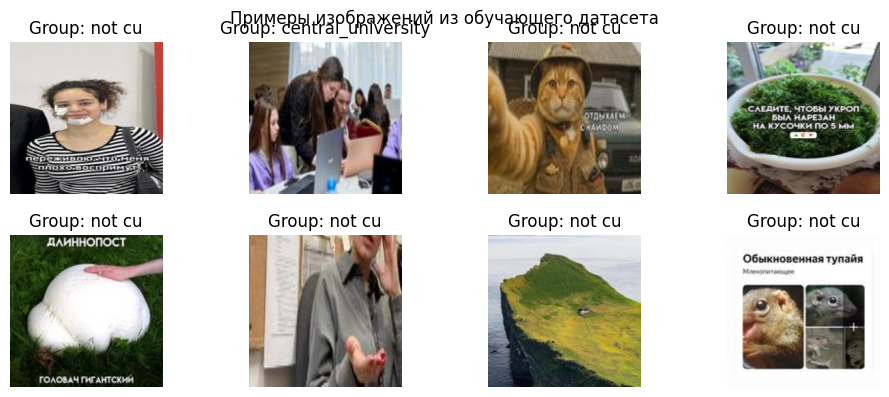

In [ ]:
import matplotlib.pyplot as plt

plt.subplots(2, 4, figsize=(10, 4))
plt.suptitle("Примеры изображений из обучающего датасета")
j = 0
for i in np.random.randint(0, len(data), 8):
    plt.subplot(2, 4, j + 1)
    j += 1
    img = data[i][0]
    label = data[i][1]
    plt.imshow(img.permute(1, 2, 0).numpy())  # Преобразуем тензор в формат [H, W, C]
    plt.title(f"Group: {groups[label]}")
    plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

### Делим на train val test, и подаем в DataLoader

In [ ]:
from torch.utils.data import random_split
import torch
torch.manual_seed(42)

train_ds, val_ds, test_ds = random_split(data, [0.6, 0.2, 0.2])

In [ ]:
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=32, shuffle=False)

### Грузим модельку

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch
from tqdm import tqdm

# assert torch.backends.mps.is_available()

# device = torch.device('mps')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.resnet18()
model.fc = nn.Linear(512, 2)
# model.add_module('softmax', nn.Softmax(dim=1))
model = model.to(device)


### Преобразуем метки чтобы все работало

In [ ]:
from sklearn.metrics import f1_score
from tqdm import tqdm

optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()
n_epochs = 10
best_score = 0

for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    total_f1 = 0

    train_iterator = tqdm(train_dl, desc=f"Epoch {epoch+1} [Train]", leave=False)
    for image, label in train_iterator:
        image, label = image.to(device), label.to(device)
        logits = model(image)
        loss = criterion(logits, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    model.eval()
    val_loss = 0
    total_f1 = 0
    val_iterator = tqdm(val_dl, desc=f"Epoch {epoch+1} [Val]", leave=False)

    with torch.no_grad():
        for image, label in val_iterator:
            image, label = image.to(device), label.to(device)
            logits = model(image)

            loss = criterion(logits, label)
            preds = logits.softmax(dim=1).argmax(dim=1)
            total_f1 += f1_score(label.cpu(), preds.cpu(), average='macro')
            val_loss += loss.item()

    total_f1 /= len(val_dl)
    val_loss /= len(val_dl)
    total_loss /= len(train_dl)

    if total_f1 > best_score:
        best_score = total_f1
        torch.save(model.state_dict(), 'best_model.pth')

    print(f'Epoch {epoch+1}: Train Loss = {total_loss:.3f}, Val Loss = {val_loss:.3f}, F1 = {total_f1:.3f}')


Epoch 1: Train Loss = 0.219, Val Loss = 0.358, F1 = 0.729


Epoch 2: Train Loss = 0.218, Val Loss = 0.402, F1 = 0.623


Epoch 3: Train Loss = 0.182, Val Loss = 0.943, F1 = 0.494


Epoch 4: Train Loss = 0.152, Val Loss = 1.329, F1 = 0.669


Epoch 5: Train Loss = 0.165, Val Loss = 0.149, F1 = 0.892


Epoch 6: Train Loss = 0.150, Val Loss = 0.116, F1 = 0.908


Epoch 7: Train Loss = 0.198, Val Loss = 0.159, F1 = 0.860


Epoch 8: Train Loss = 0.149, Val Loss = 0.138, F1 = 0.904


Epoch 9: Train Loss = 0.140, Val Loss = 0.160, F1 = 0.896


Epoch 10: Train Loss = 0.139, Val Loss = 0.123, F1 = 0.916


In [ ]:
# model = torch.load('best_model.pth', weights_only=False)

In [ ]:
model = models.resnet18()
model.fc = nn.Linear(512, 2)
model = model.to(device)
state_dict = torch.load('/content/best_model.pth')
model.load_state_dict(state_dict)

model.eval()
# test_loss = 0
# with torch.no_grad():
#     for image, label in test_dl:
#         image, label = image.to(device), label.to(device)
#         logits = model(image)
#         # loss = criterion(logits, label)
#         test_loss += loss.item()
#     test_loss /= len(test_dl)
# print(f'Test Loss = {test_loss:.3f}')

for



ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [ ]:
img = Image.open('/content/Фото 10.07.2025, 00.38.jpg')
img = transform(img)
model(img.to(device).unsqueeze(0)).softmax(dim=1).argmax(dim=1)

tensor([0], device='cuda:0')

NameError: name 'data' is not defined

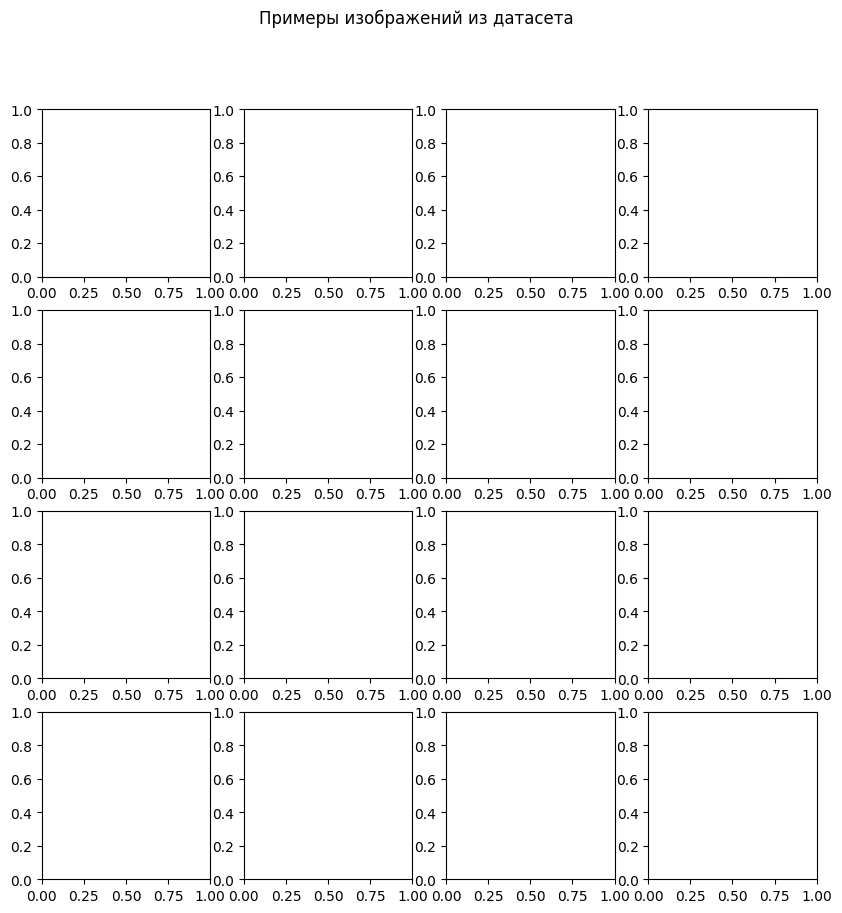

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.subplots(4, 4, figsize=(10, 10))
plt.suptitle("Примеры изображений из датасета")
j = 0
for i in np.random.randint(0, len(data), 16):
    plt.subplot(4, 4, j + 1)
    j += 1
    img = data[i][0]
    label = model(img.to(device).unsqueeze(0)).softmax(dim=1).argmax(dim=1)
    plt.imshow(img.permute(1, 2, 0).numpy())  # Преобразуем тензор в формат [H, W, C]
    plt.title(f"Group: {groups[label]}")
    plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()